In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("datasets/lifesat.csv")

In [5]:
df.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


In [6]:
df = df.drop(columns=['Country'])

In [7]:
df.head()

,GDP per capita (USD),Life satisfaction
0,26456.387938,5.8
1,27287.083401,5.4
2,28384.987785,5.5
3,29932.493910,5.9
4,31007.768407,5.6


In [12]:
df = df.rename(columns={"GDP per capita (USD)":'x','Life satisfaction':'y'})

In [13]:
df.columns

Index(['x', 'y'], dtype='object')

In [14]:
import matplotlib.pyplot as plt

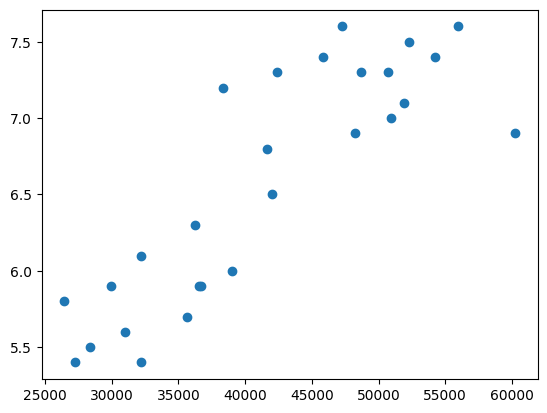

In [15]:
plt.scatter(df['x'],df['y'])

In [16]:
x_mean = df['x'].mean()

In [17]:
y_mean = df['y'].mean()

In [19]:
df['x_xmean'] = df['x']-x_mean

In [20]:
df['y_ymean'] = df['y']-y_mean

In [21]:
df['x_xmean_sq'] = df['x_xmean']**2

In [22]:
df.head()

,x,y,x_xmean,y_ymean,x_xmean_sq
0,26456.387938,5.8,-15108.133833,-0.766667,2.282557e+08
1,27287.083401,5.4,-14277.438370,-1.166667,2.038452e+08
2,28384.987785,5.5,-13179.533986,-1.066667,1.737001e+08
3,29932.493910,5.9,-11632.027861,-0.666667,1.353041e+08
4,31007.768407,5.6,-10556.753364,-0.966667,1.114450e+08


In [25]:
beta_1 = sum(df['x_xmean']*df['y_ymean'])/sum(df['x_xmean_sq'])

In [26]:
beta_1

6.77889969434122e-05

In [27]:
beta_0 = y_mean-beta_1*x_mean

In [28]:
beta_0

np.float64(3.7490494273769097)

Checking for Assumptions

In [29]:
df = pd.read_csv("datasets/Salary_Dataset.csv")

In [30]:
df.shape

(6704, 3)

In [31]:
df.head()

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0


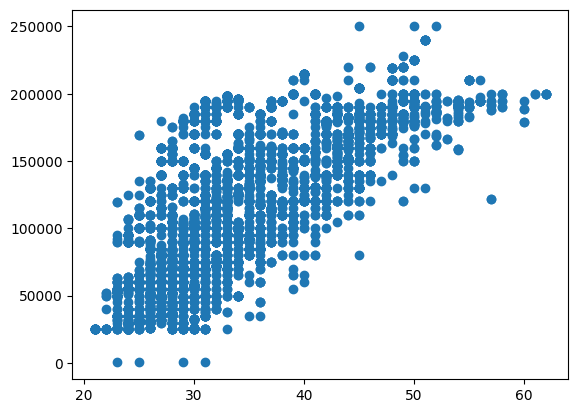

In [32]:
plt.scatter(df['Age'],df['Salary'])

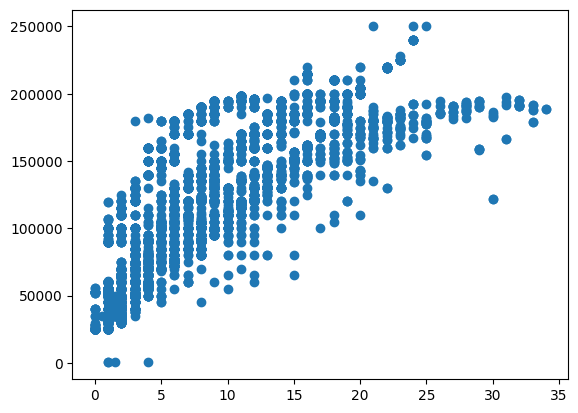

In [33]:
plt.scatter(df['Years of Experience'],df['Salary'])

In [34]:
df.corr()

,Age,Years of Experience,Salary
Age,1.000000,0.937655,0.728053
Years of Experience,0.937655,1.000000,0.808969
Salary,0.728053,0.808969,1.000000


In [35]:
import seaborn as sns

<Axes: >

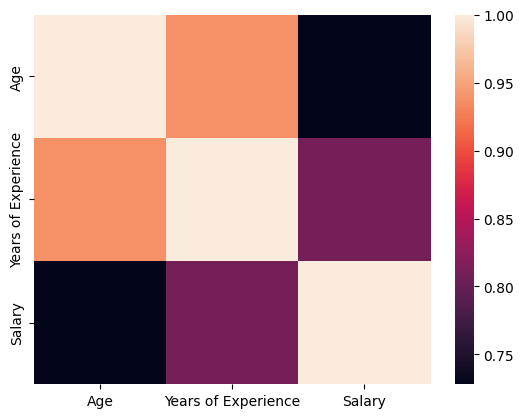

In [36]:
sns.heatmap(df.corr())

In [37]:
!pip install statsmodels

  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/df/4c/2feda3a9f0e17444a84ba5398ada6a4d2e1b8f832760048f04e2b8ea0c41/statsmodels-0.14.5-cp312-cp312-win_amd64.whl.metadata
  Using cached statsmodels-0.14.5-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
  Obtaining dependency information for patsy>=0.5.6 from https://files.pythonhosted.org/packages/f1/70/ba4b949bdc0490ab78d545459acd7702b211dfccf7eb89bbc1060f52818d/patsy-1.0.2-py2.py3-none-any.whl.metadata
Using cached statsmodels-0.14.5-cp312-cp312-win_amd64.whl (9.6 MB)
   ---------------------------------------- 0.0/233.3 kB ? eta -:--:--
   - -------------------------------------- 10.2/233.3 kB ? eta -:--:--
   ------ -------------------------------- 41.0/233.3 kB 495.5 kB/s eta 0:00:01
   ---------------- --------------------- 102.4/233.3 kB 845.5 kB/s eta 0:00:01
   ----------------------------------- ---- 204.8/233.3 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 233.3


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

In [40]:
df.head()

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0


In [43]:
df.isna().sum()

Age                    2
Years of Experience    3
Salary                 5
dtype: int64

In [44]:
df = df.dropna()

In [45]:
X = df.drop(columns=['Salary'])
y = df['Salary']

In [48]:
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 

In [49]:
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X, i) 
                          for i in range((X.shape[1]))] 

In [50]:
vif_data

,feature,VIF
0,Age,5.520692
1,Years of Experience,5.520692


In [52]:
X.shape[1]

2